# **Healthcare Service Utilization Analysis Using Python**

## **Business Problem**
Healthcare organizations and policymakers need to understand how healthcare services are utilized across different regions, age groups, genders, and insurance payer types. Without proper analysis, it is difficult to identify utilization trends, allocate healthcare resources efficiently, and support data-driven healthcare planning. This project analyzes California healthcare service utilization data (2021–2023) to uncover meaningful insights that can assist in healthcare decision-making.

## **Project Objectives**

* To identify the most utilized healthcare service categories across
California between 2021 to 2023.
* To compare healthcare service utilization across different insurance payer types to understand variations in service demand.
* To analyze demographic and regional variations in healthcare service utilization based on age group, assigned sex at birth, county, and Covered California region.
* To evaluate insurance coverage patterns by analyzing medical coverage months across different payer types and counties.
* To identify healthcare utilization trends over the period 2021 to 2023 and examine changes in service demand across different healthcare service categories.
* To generate actionable insights that support healthcare planning, resource allocation, and data-driven decision-making.

## **Dataset Information**

Source: California Health and Human Services (CalHHS) – Healthcare Payments Data (HPD) Services Report

Location: California, USA

Year/Timeline: 2021–2023 (Filtered from the original dataset covering 2018–2023)

Domain: Healthcare Analytics

In [ ]:
#Importing Libraries
import numpy as np
import pandas as pd
#Displaying The Floating-point numbers in normal format
pd.options.display.float_format = '{:,.2f}'.format
#Importing Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


In [ ]:
#Data Loaded From Github
url = "https://raw.githubusercontent.com/Suriya-Data-Analyst/Healthcare-Service-Utilization-Analysis-Using-Python/refs/heads/main/services_rpt_data-service-category.csv"

In [ ]:
#Csv file is converted to datafarme with pandas
df = pd.read_csv(url)

In [ ]:
#Verifying The Dataset Shape
print(df.shape)

(120960, 12)


## **Initial Inspection / Initial EDA**



In [ ]:
# Displaying first 5 rows
df.head()

,reporting_year,age_band,assigned_sex_at_birth,county_name,county_name_plus_spa,covered_california_region,payer_type,service_category,member_count,medical_coverage_months,service_count,suppression_ind
0,2018,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Anesthesia,970.00,"871,724.00","1,132.00",N
1,2018,0-17,Female,Alameda,Alameda,Alameda County,Commercial,DME,"2,480.00","871,724.00","4,496.00",N
2,2018,0-17,Female,Alameda,Alameda,Alameda County,Commercial,E&M,"65,138.00","871,724.00","258,239.00",N
3,2018,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Imaging,"11,741.00","871,724.00","20,779.00",N
4,2018,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Other,"3,773.00","871,724.00","4,872.00",N


In [ ]:
# To evaluate data health, check for missing values, and monitor memory consumption.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120960 entries, 0 to 120959
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   reporting_year             120960 non-null  int64  
 1   age_band                   120960 non-null  object 
 2   assigned_sex_at_birth      120960 non-null  object 
 3   county_name                120960 non-null  object 
 4   county_name_plus_spa       120960 non-null  object 
 5   covered_california_region  120960 non-null  object 
 6   payer_type                 120960 non-null  object 
 7   service_category           120960 non-null  object 
 8   member_count               107956 non-null  float64
 9   medical_coverage_months    107956 non-null  float64
 10  service_count              107956 non-null  float64
 11  suppression_ind            120960 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 11.1+ MB


In [ ]:
#To understand the attribute and to check  the column labels
df.columns

Index(['reporting_year', 'age_band', 'assigned_sex_at_birth', 'county_name',
       'county_name_plus_spa', 'covered_california_region', 'payer_type',
       'service_category', 'member_count', 'medical_coverage_months',
       'service_count', 'suppression_ind'],
      dtype='object')

In [ ]:
#To understand quick statistical summary of your DataFrame
df.describe()

,reporting_year,member_count,medical_coverage_months,service_count
count,"120,960.00","107,956.00","107,956.00","107,956.00"
mean,"2,020.50","5,141.49","170,036.20","24,935.05"
std,1.71,"12,081.23","312,535.53","71,589.30"
min,"2,018.00",0.00,0.00,0.00
25%,"2,019.00",195.00,"7,691.00",558.00
50%,"2,020.50",884.00,"33,997.00","2,958.00"
75%,"2,022.00","3,957.25","174,199.00","15,295.25"
max,"2,023.00","146,880.00","2,128,166.00","1,935,875.00"


In [ ]:
#Checking the datatypes
df.dtypes


,0
reporting_year,int64
age_band,object
assigned_sex_at_birth,object
county_name,object
county_name_plus_spa,object
covered_california_region,object
payer_type,object
service_category,object
member_count,float64
medical_coverage_months,float64


In [ ]:
#Finding The Duplicate Values
df.duplicated().sum()

np.int64(0)

In [ ]:
#Finding The Empty Cells
df.isnull().sum()

,0
reporting_year,0
age_band,0
assigned_sex_at_birth,0
county_name,0
county_name_plus_spa,0
covered_california_region,0
payer_type,0
service_category,0
member_count,13004
medical_coverage_months,13004


## **Data Cleaning**

In [ ]:
#Finding The Duplicate Values
df.duplicated().sum()

np.int64(0)

In [ ]:
#Finding The Empty Cells
df.isnull().sum()

,0
reporting_year,0
age_band,0
assigned_sex_at_birth,0
county_name,0
county_name_plus_spa,0
covered_california_region,0
payer_type,0
service_category,0
member_count,13004
medical_coverage_months,13004


In [ ]:
#Filtering The Dataset The Reporting Years From 2021–2023
df = df[df["reporting_year"].isin([2021, 2022, 2023])]

In [ ]:
#Checking The Duplicates After Filtering The Years
print("Duplicates after filtering years:", df.duplicated().sum())

Duplicates after filtering years: 0


In [ ]:
#Checking The Reporting Years After Filtering
df["reporting_year"].unique()

array([2021, 2022, 2023])

In [ ]:
#Check the shape of the filtered dataset
df.shape

(60480, 12)

In [ ]:
#Removing Rows with Zero Member Count
df = df[df["member_count"] != 0]

In [ ]:
#Checking The Duplicates After Removing The Rows With Zero
print("Duplicates after Removing The Rows With Zero:", df.duplicated().sum())

Duplicates after Removing The Rows With Zero: 0


In [ ]:
#Checking Rows With Zero Member Count
(df["member_count"] == 0).sum()

np.int64(0)

In [ ]:
#Checking The Shape After Removing Zero Member Count Rows
df.shape

(57555, 12)

In [ ]:
#Displaying The Data After Filtering The Years & Removing The Rows With 0
df

,reporting_year,age_band,assigned_sex_at_birth,county_name,county_name_plus_spa,covered_california_region,payer_type,service_category,member_count,medical_coverage_months,service_count,suppression_ind
60480,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Anesthesia,794.00,"857,723.00",926.00,N
60481,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,DME,"1,390.00","857,723.00","2,966.00",N
60482,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,E&M,"62,060.00","857,723.00","282,830.00",N
60483,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Imaging,"10,112.00","857,723.00","19,190.00",N
60484,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Other,"2,558.00","857,723.00","4,100.00",N
...,...,...,...,...,...,...,...,...,...,...,...,...
120955,2023,75+,Male,Yuba,Yuba,Northern Counties,Medicare,Imaging,"1,358.00","21,876.00","8,085.00",N
120956,2023,75+,Male,Yuba,Yuba,Northern Counties,Medicare,Other,562.00,"21,876.00","1,163.00",N
120957,2023,75+,Male,Yuba,Yuba,Northern Counties,Medicare,Procedure,"1,086.00","21,876.00","4,269.00",N
120958,2023,75+,Male,Yuba,Yuba,Northern Counties,Medicare,Test,"1,564.00","21,876.00","13,595.00",N


In [ ]:
#Reseting The Index After Filtering
df.reset_index(drop=True, inplace=True)

In [ ]:
#Verifying The Index
df

,reporting_year,age_band,assigned_sex_at_birth,county_name,county_name_plus_spa,covered_california_region,payer_type,service_category,member_count,medical_coverage_months,service_count,suppression_ind
0,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Anesthesia,794.00,"857,723.00",926.00,N
1,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,DME,"1,390.00","857,723.00","2,966.00",N
2,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,E&M,"62,060.00","857,723.00","282,830.00",N
3,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Imaging,"10,112.00","857,723.00","19,190.00",N
4,2021,0-17,Female,Alameda,Alameda,Alameda County,Commercial,Other,"2,558.00","857,723.00","4,100.00",N
...,...,...,...,...,...,...,...,...,...,...,...,...
57550,2023,75+,Male,Yuba,Yuba,Northern Counties,Medicare,Imaging,"1,358.00","21,876.00","8,085.00",N
57551,2023,75+,Male,Yuba,Yuba,Northern Counties,Medicare,Other,562.00,"21,876.00","1,163.00",N
57552,2023,75+,Male,Yuba,Yuba,Northern Counties,Medicare,Procedure,"1,086.00","21,876.00","4,269.00",N
57553,2023,75+,Male,Yuba,Yuba,Northern Counties,Medicare,Test,"1,564.00","21,876.00","13,595.00",N


In [ ]:
#Finding The Duplicate Values After Filtering
df.duplicated().sum()

np.int64(0)

In [ ]:
#Finding The Empty Cells After Filtering
df.isnull().sum()

,0
reporting_year,0
age_band,0
assigned_sex_at_birth,0
county_name,0
county_name_plus_spa,0
covered_california_region,0
payer_type,0
service_category,0
member_count,6537
medical_coverage_months,6537


In [ ]:
#Removing The Unwanted Columns
df.drop(columns=["county_name_plus_spa", "suppression_ind"], inplace=True)

In [ ]:
#Checking The Duplicates After Removing Unwanted Columns
print("Duplicates after Removing Unwanted Columns:", df.duplicated().sum())

Duplicates after Removing Unwanted Columns: 262


<b>Note:</b><br>
Dropping the non-essential columns causes 262 rows to appear duplicated.
These are not actual duplicate records in the original dataset, so they are retained for analysis.

In [ ]:
#Checking The Dataset After Removing Unwanted Colummns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57555 entries, 0 to 57554
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   reporting_year             57555 non-null  int64  
 1   age_band                   57555 non-null  object 
 2   assigned_sex_at_birth      57555 non-null  object 
 3   county_name                57555 non-null  object 
 4   covered_california_region  57555 non-null  object 
 5   payer_type                 57555 non-null  object 
 6   service_category           57555 non-null  object 
 7   member_count               51018 non-null  float64
 8   medical_coverage_months    51018 non-null  float64
 9   service_count              51018 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 4.4+ MB


In [ ]:
#Displaying The First 5 Rows After Removing Unwanted Columns
df.head()

,reporting_year,age_band,assigned_sex_at_birth,county_name,covered_california_region,payer_type,service_category,member_count,medical_coverage_months,service_count
0,2021,0-17,Female,Alameda,Alameda County,Commercial,Anesthesia,794.00,"857,723.00",926.00
1,2021,0-17,Female,Alameda,Alameda County,Commercial,DME,"1,390.00","857,723.00","2,966.00"
2,2021,0-17,Female,Alameda,Alameda County,Commercial,E&M,"62,060.00","857,723.00","282,830.00"
3,2021,0-17,Female,Alameda,Alameda County,Commercial,Imaging,"10,112.00","857,723.00","19,190.00"
4,2021,0-17,Female,Alameda,Alameda County,Commercial,Other,"2,558.00","857,723.00","4,100.00"


In [ ]:
#Data Imputation(Handling Missing Values)
#Analyzing The Distribution Of Numeric Columns To Choose The Appropriate Imputation
df[["member_count", "medical_coverage_months", "service_count"]].describe()

,member_count,medical_coverage_months,service_count
count,"51,018.00","51,018.00","51,018.00"
mean,"5,644.51","183,723.46","28,445.42"
std,"12,780.19","323,826.44","79,612.49"
min,30.00,12.00,31.00
25%,254.00,"10,161.00",759.00
50%,"1,046.00","41,960.00","3,579.00"
75%,"4,484.00","199,906.00","17,865.50"
max,"146,880.00","2,128,166.00","1,935,875.00"


In [ ]:
#Filling Missing Values Using Median Within Payer Type and Service Category
df["member_count"] = df.groupby(
    ["payer_type", "service_category"]
)["member_count"].transform(lambda x: x.fillna(x.median()))

df["medical_coverage_months"] = df.groupby(
    ["payer_type", "service_category"]
)["medical_coverage_months"].transform(lambda x: x.fillna(x.median()))

df["service_count"] = df.groupby(
    ["payer_type", "service_category"]
)["service_count"].transform(lambda x: x.fillna(x.median()))

In [ ]:
#Checking The Duplicates After Imputing Missing Values
print("Duplicates after Imputing Missing Values:", df.duplicated().sum())

Duplicates after Imputing Missing Values: 262


In [ ]:
#Checking Missing Values After Categoy Based Imputation
df.isnull().sum()

,0
reporting_year,0
age_band,0
assigned_sex_at_birth,0
county_name,0
covered_california_region,0
payer_type,0
service_category,0
member_count,0
medical_coverage_months,0
service_count,0


## **Data Transformaton**

In [ ]:
#Checking The Data Types
df.dtypes

,0
reporting_year,int64
age_band,object
assigned_sex_at_birth,object
county_name,object
covered_california_region,object
payer_type,object
service_category,object
member_count,float64
medical_coverage_months,float64
service_count,float64


In [ ]:
#Checking Unique Values In Categorical Columns
categorical_cols = [
    "age_band",
    "assigned_sex_at_birth",
    "county_name",
    "covered_california_region",
    "payer_type",
    "service_category"]
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


age_band
['0-17' '18-34' '35-49' '50-64' '65-74' '75+']

assigned_sex_at_birth
['Female' 'Male']

county_name
['Alameda' 'Alpine' 'Amador' 'Butte' 'Calaveras' 'Colusa' 'Contra Costa'
 'Del Norte' 'El Dorado' 'Fresno' 'Glenn' 'Humboldt' 'Imperial' 'Inyo'
 'Kern' 'Kings' 'Lake' 'Lassen' 'Los Angeles' 'Madera' 'Marin' 'Mariposa'
 'Mendocino' 'Merced' 'Modoc' 'Mono' 'Monterey' 'Napa' 'Nevada' 'Orange'
 'Placer' 'Plumas' 'Riverside' 'Sacramento' 'San Benito' 'San Bernardino'
 'San Diego' 'San Francisco' 'San Joaquin' 'San Luis Obispo' 'San Mateo'
 'Santa Barbara' 'Santa Clara' 'Santa Cruz' 'Shasta' 'Sierra' 'Siskiyou'
 'Solano' 'Sonoma' 'Stanislaus' 'Sutter' 'Tehama' 'Trinity' 'Tulare'
 'Tuolumne' 'Ventura' 'Yolo' 'Yuba']

covered_california_region
['Alameda County' 'Northern Counties' 'Contra Costa County'
 'Greater Sacramento' 'Fresno, Kings, Madera Counties' 'Eastern Counties'
 'Kern County' 'Los Angeles County East' 'Los Angeles County West'
 'North Bay Area' 'Central Valley'
 'Santa C

### **Feature Engineering**

In [ ]:
# Creating Average Services Per Member
df["avg_services_per_member"] = (
    df["service_count"] / df["member_count"]
)

In [ ]:
#Checking The Duplicates After Creating a Average Services Per Member Column
print("Duplicates after avg_services_per_member:", df.duplicated().sum())

Duplicates after avg_services_per_member: 262


In [ ]:
#Checking The Unique values in avg_services_per_member column
df['avg_services_per_member'].unique()

array([1.16624685, 2.13381295, 4.55736384, ..., 3.93093923, 8.69245524,
       5.97572816])

In [ ]:
# Creating Utilization Level (Low, Medium, High) Based on Average Services Per Member
df["utilization_level"] = pd.qcut(
    df["avg_services_per_member"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [ ]:
#Checking The Duplicates After Creating a utilization_level Column
print("Duplicates after utilization_level:", df.duplicated().sum())

Duplicates after utilization_level: 262


In [ ]:
# Checking Unique Values in utilization_level
df["utilization_level"].unique()

['Low', 'Medium', 'High']
Categories (3, object): ['Low' < 'Medium' < 'High']

## **Final Inspection/Final EDA**

In [ ]:
#Displaying The First 5 Rows
df.head()

,reporting_year,age_band,assigned_sex_at_birth,county_name,covered_california_region,payer_type,service_category,member_count,medical_coverage_months,service_count,avg_services_per_member,utilization_level
0,2021,0-17,Female,Alameda,Alameda County,Commercial,Anesthesia,794.00,"857,723.00",926.00,1.17,Low
1,2021,0-17,Female,Alameda,Alameda County,Commercial,DME,"1,390.00","857,723.00","2,966.00",2.13,Low
2,2021,0-17,Female,Alameda,Alameda County,Commercial,E&M,"62,060.00","857,723.00","282,830.00",4.56,Medium
3,2021,0-17,Female,Alameda,Alameda County,Commercial,Imaging,"10,112.00","857,723.00","19,190.00",1.90,Low
4,2021,0-17,Female,Alameda,Alameda County,Commercial,Other,"2,558.00","857,723.00","4,100.00",1.60,Low


In [ ]:
#Displaying The Last 5 Rows
df.tail()

,reporting_year,age_band,assigned_sex_at_birth,county_name,covered_california_region,payer_type,service_category,member_count,medical_coverage_months,service_count,avg_services_per_member,utilization_level
57550,2023,75+,Male,Yuba,Northern Counties,Medicare,Imaging,"1,358.00","21,876.00","8,085.00",5.95,High
57551,2023,75+,Male,Yuba,Northern Counties,Medicare,Other,562.00,"21,876.00","1,163.00",2.07,Low
57552,2023,75+,Male,Yuba,Northern Counties,Medicare,Procedure,"1,086.00","21,876.00","4,269.00",3.93,Medium
57553,2023,75+,Male,Yuba,Northern Counties,Medicare,Test,"1,564.00","21,876.00","13,595.00",8.69,High
57554,2023,75+,Male,Yuba,Northern Counties,Medicare,Treatment,"1,236.00","21,876.00","7,386.00",5.98,High


In [ ]:
#Displaying The Dataset Shape
df.shape

(57555, 12)

In [ ]:
#Displaying The Data Types
df.dtypes

,0
reporting_year,int64
age_band,object
assigned_sex_at_birth,object
county_name,object
covered_california_region,object
payer_type,object
service_category,object
member_count,float64
medical_coverage_months,float64
service_count,float64


In [ ]:
#Displaying The Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57555 entries, 0 to 57554
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   reporting_year             57555 non-null  int64   
 1   age_band                   57555 non-null  object  
 2   assigned_sex_at_birth      57555 non-null  object  
 3   county_name                57555 non-null  object  
 4   covered_california_region  57555 non-null  object  
 5   payer_type                 57555 non-null  object  
 6   service_category           57555 non-null  object  
 7   member_count               57555 non-null  float64 
 8   medical_coverage_months    57555 non-null  float64 
 9   service_count              57555 non-null  float64 
 10  avg_services_per_member    57555 non-null  float64 
 11  utilization_level          57555 non-null  category
dtypes: category(1), float64(4), int64(1), object(6)
memory usage: 4.9+ MB


In [ ]:
#Checking The Shape & Duplicates
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape: (57555, 12)
Duplicates: 262


In [ ]:
#Displaying The Missing Values
df.isnull().sum()

,0
reporting_year,0
age_band,0
assigned_sex_at_birth,0
county_name,0
covered_california_region,0
payer_type,0
service_category,0
member_count,0
medical_coverage_months,0
service_count,0


In [ ]:
#Displaying The Statistical Summary
df.describe()

,reporting_year,member_count,medical_coverage_months,service_count,avg_services_per_member
count,"57,555.00","57,555.00","57,555.00","57,555.00","57,555.00"
mean,"2,022.00","5,109.25","168,068.71","25,719.79",4.17
std,0.82,"12,127.34","308,099.37","75,361.58",2.98
min,"2,021.00",30.00,12.00,31.00,1.00
25%,"2,021.00",309.00,"12,113.00",781.00,1.96
50%,"2,022.00",968.00,"43,501.00","3,273.00",3.41
75%,"2,023.00","3,715.00","161,208.00","15,065.50",5.43
max,"2,023.00","146,880.00","2,128,166.00","1,935,875.00",23.57


## **Statistical Analysis**

In [ ]:
#Numerical Columns For Central Tendency Analysis
num_col = [
    'member_count',
    'medical_coverage_months',
    'service_count',
    'avg_services_per_member']


In [ ]:
#Summary Table
summary_table = pd.DataFrame({
    'Mean': df[num_col].mean(),
    'Median': df[num_col].median(),
    'Mode': df[num_col].mode().iloc[0]})

In [ ]:
#Displaying the table
print("MEASURE OF CENTRAL TENDENCY\n")
summary_table

MEASURE OF CENTRAL TENDENCY



,Mean,Median,Mode
member_count,"5,109.25",968.00,378.00
medical_coverage_months,"168,068.71","43,501.00","91,822.00"
service_count,"25,719.79","3,273.00",528.00
avg_services_per_member,4.17,3.41,1.40


(57555, 12)


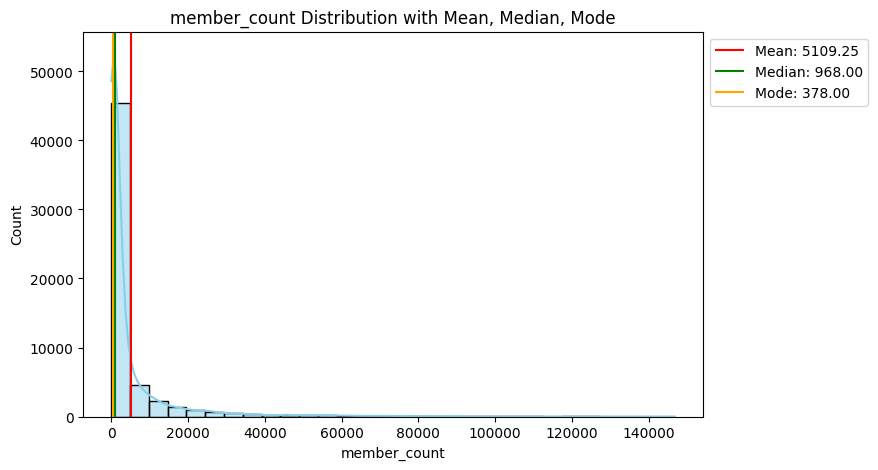

(57555, 12)


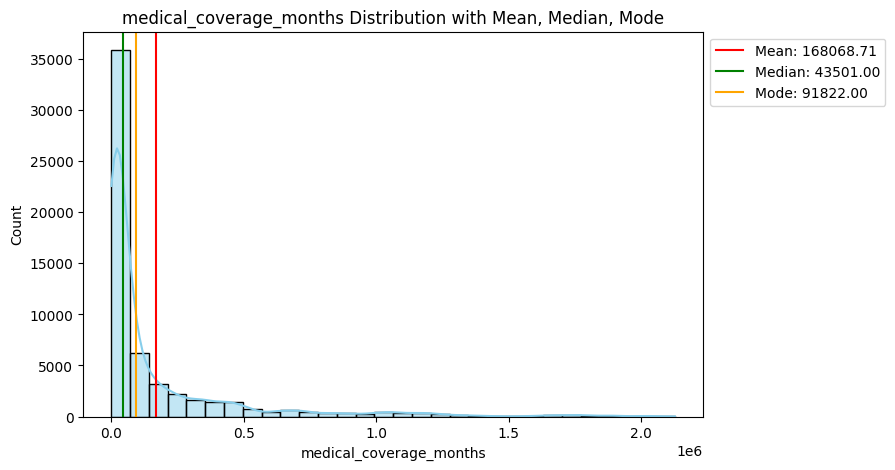

(57555, 12)


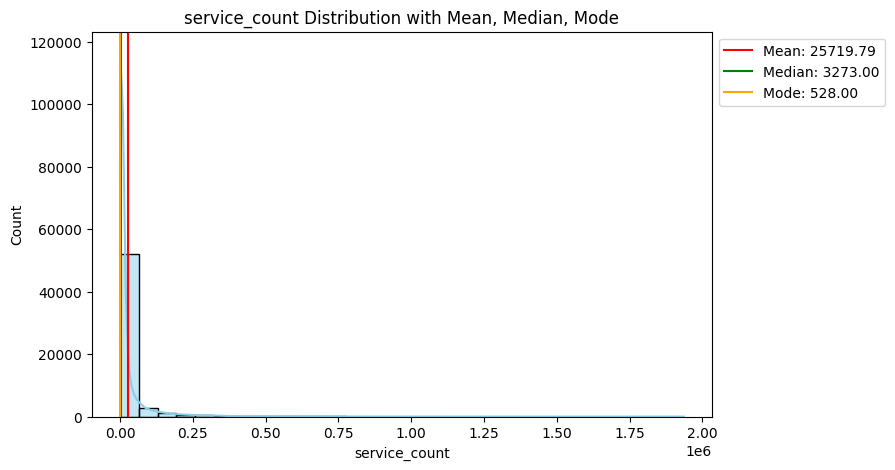

(57555, 12)


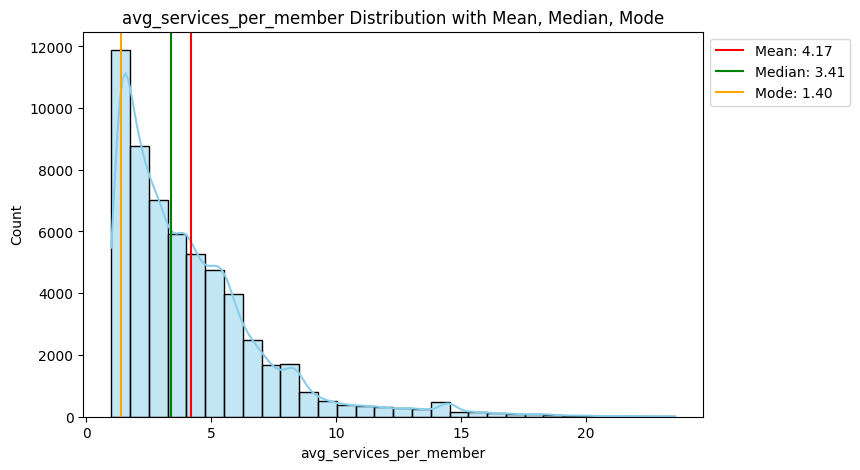

In [ ]:
#Histogram With Mean, Median and Mode
for col in num_col:

    #Getting the calculated values from summary table
    mean_val = summary_table.loc[col, 'Mean']
    median_val = summary_table.loc[col, 'Median']
    mode_val = summary_table.loc[col, 'Mode']

    #Setting the chart canvas size
    plt.figure(figsize=(8,5))
    print(df.shape)

    #Plotting Histogram With KDE Curve
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')

    #Adding Vertical Lines For Mean, Median & Mode
    plt.axvline(mean_val, color='red', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', label=f'Median: {median_val:.2f}')
    plt.axvline(mode_val, color='orange', label=f'Mode: {mode_val:.2f}')

    #Adding titles and clean text labels
    plt.title(f'{col} Distribution with Mean, Median, Mode')
    plt.legend(loc='upper left', bbox_to_anchor=(1,1))

    #Viewing the chart
    plt.show()




## INTERPRETATION: Measure of Central Tendency Analysis

**The Blue Bars (Histogram):** Show the distribution of healthcare service utilization metrics across different groups.

**The Blue Curve (KDE):** Displays the overall distribution pattern and confirms that most observations are concentrated at lower values.

**The Orange Line (Mode):** Represents the most frequently occurring value in each healthcare metric.

**The Green Line (Median):** Represents the middle value of the dataset and provides a reliable measure of the typical healthcare utilization.

**The Red Line (Mean):** Represents the mathematical average. In all four variables, the Mean lies to the right of the Median, indicating positively skewed distributions. This suggests that a small number of records with exceptionally high values are increasing the overall averages.

## Insights

- **Member Count:** Most healthcare groups contain relatively fewer members, while a few groups have very large populations. The mean (5,109.25) is higher than the median (968.00) and mode (378.00), indicating a right-skewed distribution.

- **Medical Coverage Months:** Most observations have lower coverage months, while a few groups record exceptionally high values. The mean (168,068.71) exceeds the median (43,501.00) and mode (91,822.00), indicating positive skewness.

- **Service Count:** Most groups utilize relatively fewer healthcare services, while a limited number record very high service usage. The mean (25,719.79) is much higher than the median (3,273.00) and mode (528.00).

- **Average Services per Member:** Most members utilize healthcare services at a moderate rate, while a few have substantially higher utilization. The mean (4.17) is greater than the median (3.41) and mode (1.40), indicating positive skewness.

- **Overall Distribution:** All four variables exhibit positive (right) skewness, where the mean is greater than the median, indicating that high-value observations increase the overall average.

- **Possible Outliers:** The long right tails in the histograms suggest potential outliers, which should be verified using a Box Plot or the IQR method before any treatment.

## **Variance**

In [ ]:
#Measure of Dispersion - Variance
variance_table = df[num_col].var().to_frame(name="Variance")
print("MEASURE OF DISPERSION: VARIANCE\n")
print(variance_table)

MEASURE OF DISPERSION: VARIANCE

                                 Variance
member_count               147,072,363.64
medical_coverage_months 94,925,221,933.13
service_count            5,679,367,784.22
avg_services_per_member              8.90


## **Box Plot**

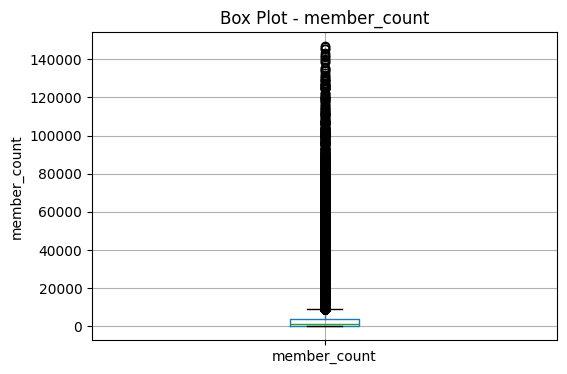

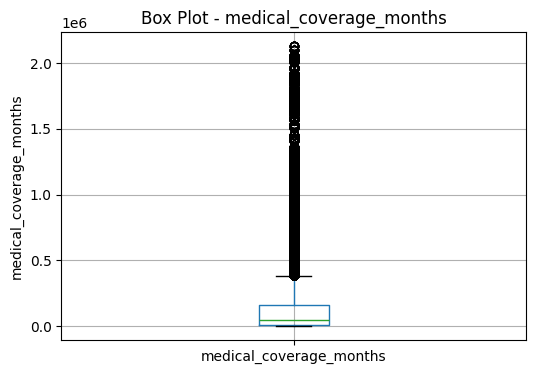

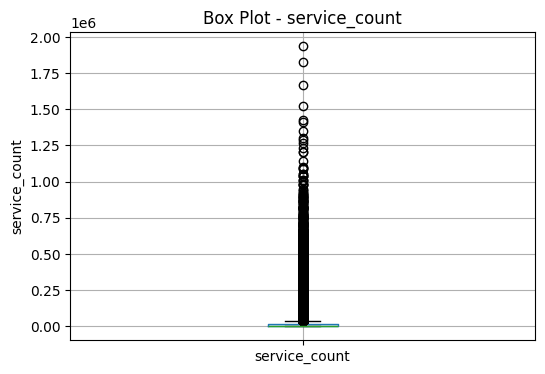

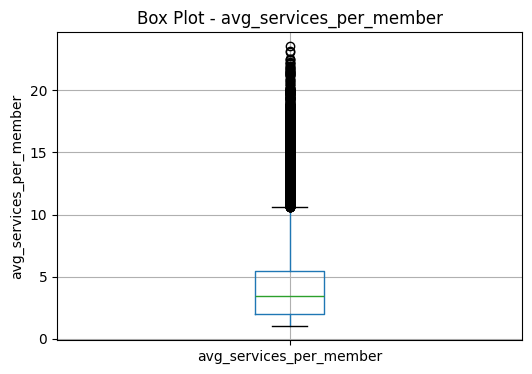

In [ ]:
#Loop through each numerical column
#Box Plot For Dispersion Analysis
for col in num_col:
# Set chart size
    plt.figure(figsize=(6,4))
# Draw box plot
    df.boxplot(column=col)
# Add title and y-axis label
    plt.title(f'Box Plot - {col}')
    plt.ylabel(col)
# Display chart
    plt.show()

## INTERPRETATION: Variance and Box Plot Analysis

The **Variance** measures how much each healthcare utilization metric varies from its average value. Higher **variance** indicates greater variability among healthcare groups, while lower **variance** indicates more consistent values.

The **Box Plot** visualizes the distribution of each variable and helps identify the spread of the data, median, and potential outliers. The presence of observations beyond the whiskers suggests potential outliers in the dataset.

## Insights

- **Member Count:** The box plot shows several upper outliers, indicating large differences in member populations. The variance (147,072,363.64) confirms a wide spread in member counts.

- **Medical Coverage Months:** This variable has the widest spread and the highest number of upper outliers. The highest variance (94,925,221,933.13) indicates substantial variation in coverage months.

- **Service Count:** Several upper outliers indicate that a few healthcare groups record exceptionally high service utilization. The variance (5,679,367,784.22) confirms considerable variability.

- **Average Services per Member:** Most values are concentrated within a smaller range with fewer extreme outliers. The lowest variance (8.90) indicates relatively consistent utilization per member.

- **Overall Observation:** All four box plots contain upper outliers, showing that a small number of healthcare groups have unusually high values compared to the majority of the dataset.

## **Standard Deviation**

In [ ]:
#Measure of Dispersion - Standard Deviation
std_table = df[num_col].std().to_frame(name="Standard Deviation")
print("MEASURE OF DISPERSION: STANDARD DEVIATION\n")
print(std_table)

MEASURE OF DISPERSION: STANDARD DEVIATION

                         Standard Deviation
member_count                      12,127.34
medical_coverage_months          308,099.37
service_count                     75,361.58
avg_services_per_member                2.98


## INTERPRETATION: Standard Deviation Analysis

The **Standard Deviation** measures how much the data varies from the mean. A higher standard deviation indicates greater variability, while a lower standard deviation indicates more consistent values.

## Insights

- **Member Count:** Shows moderate variation across healthcare groups with a standard deviation of 12,127.34, indicating noticeable differences in member populations.

- **Medical Coverage Months:** Has the highest standard deviation (308,099.37), indicating the greatest variability in healthcare coverage months.

- **Service Count:** Shows high variation in healthcare service utilization with a standard deviation of 75,361.58 across healthcare groups.

- **Average Services per Member:** Has the lowest standard deviation (2.98), indicating relatively consistent service utilization per member.

- **Overall Observation:** Medical Coverage Months and Service Count show the greatest variability, while Average Services per Member is the most consistent variable.

## **Deviation From Mean**

In [ ]:
# Calculate mean for each numerical column
means = df[num_col].mean()
# Calculate deviation from mean
deviation = df[num_col] - means

## **Deviation Chart**

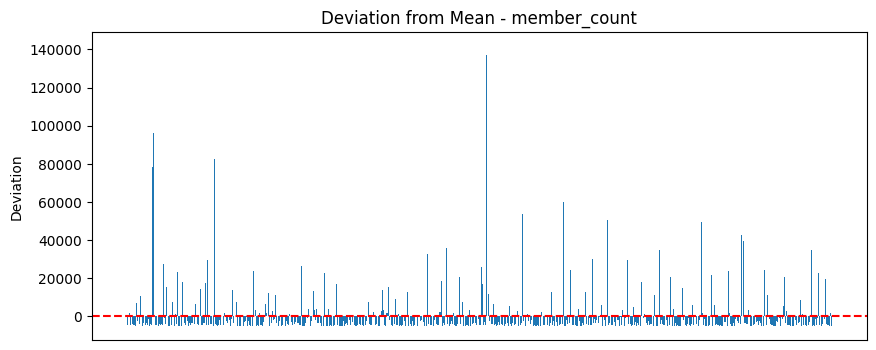

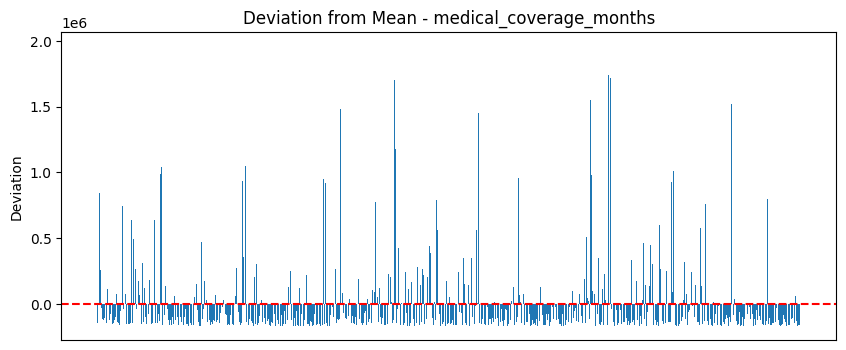

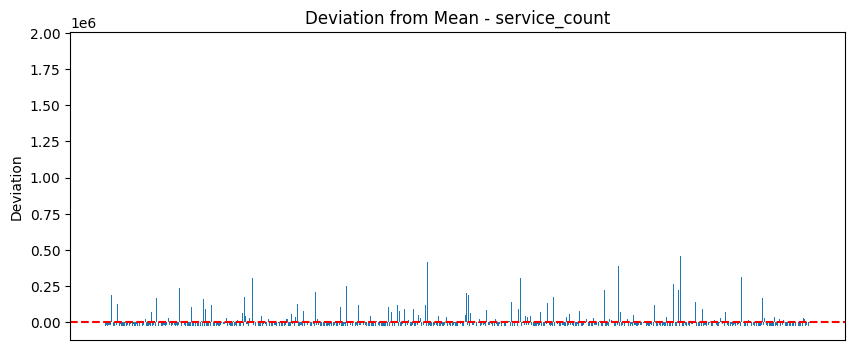

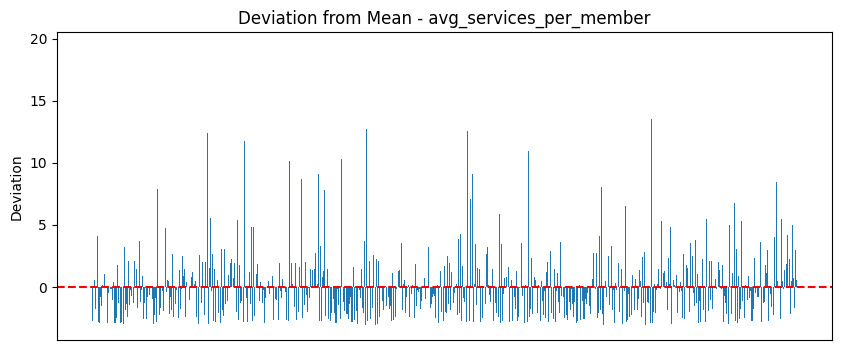

In [ ]:
#Deviation Chart For Dispersion Analysis
#Loop through each numerical column
for col in num_col:
#Set chart size
    plt.figure(figsize=(10,4))
#Plot deviation from the mean
    plt.bar(range(len(deviation)), deviation[col])
#Add reference line at zero (Mean)
    plt.axhline(0, color='red', linestyle='--')
#Add chart title
    plt.title(f'Deviation from Mean - {col}')
#Add y-axis label
    plt.ylabel("Deviation")
#Remove x-axis labels for better readability
    plt.xticks([])
#Display chart
    plt.show()

## INTERPRETATION: Deviation from Mean Analysis

The **Deviation from Mean** chart shows how far each observation is from the average value. Values above the red line are higher than the mean, while values below the red line are lower than the mean. Larger deviations indicate greater variation in the data.

## Insights

- **Member Count:** Most observations are close to the mean, while a few healthcare groups have substantially higher member counts.

- **Medical Coverage Months:** Shows the largest deviations from the mean, indicating considerable variation in healthcare coverage across groups.

- **Service Count:** Most healthcare groups have lower service utilization, while a few groups record significantly higher service usage.

- **Average Services per Member:** Deviations are relatively small, indicating more consistent healthcare utilization per member.

- **Overall Observation:** All variables contain a few observations that deviate substantially from the mean, suggesting uneven healthcare utilization across different groups.

##**Data Visualisation**

##**Univariate Analysis**

**Objective 1 - To identify the most utilized healthcare service categories across California between 2021 and 2023**

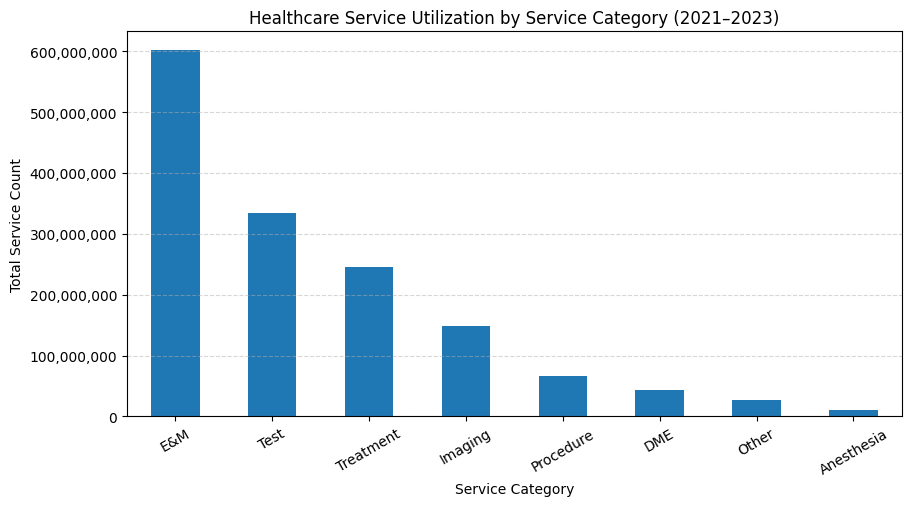

In [ ]:
# Group data by service category and calculate total service count
service_utilization = (df.groupby("service_category")["service_count"].sum().sort_values(ascending=False))
# Sort from highest to lowest utilization

# Set chart size
plt.figure(figsize=(10,5))
# Plot bar chart
service_utilization.plot(kind="bar")
# Add chart title
plt.title("Healthcare Service Utilization by Service Category (2021–2023)")
# Add x-axis label
plt.xlabel("Service Category")
# Add y-axis label
plt.ylabel("Total Service Count")
# Rotate x-axis labels for better readability
plt.xticks(rotation=30)
# Add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Display y-axis in normal number format
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
# Displaying the chart
plt.show()

### Interpretation & Insights

- **Most Utilized Service:** This Bar chart shows the distribution of healthcare service utilization across different service categories and it shows the E&M records the highest healthcare service utilization between 2021 to 2023, followed by Test and Treatment, indicating the greatest demand for these services.

- **Moderately Utilized Services:** Imaging shows moderate utilization, while Procedure and DME contribute a comparatively smaller share of total healthcare services.

- **Least Utilized Services:** Other and Anesthesia record the lowest service utilization, reflecting limited demand compared to the major service categories.

- **Overall Observation:** Healthcare service utilization is unevenly distributed, with E&M accounting for a significantly larger share than the remaining service categories.

- **Business Insight:** Identifying high-demand service categories helps healthcare organizations optimize resource allocation, workforce planning, and service delivery.

**Objective 2 - To compare healthcare service utilization across different insurance payer types to understand variations in service demand**

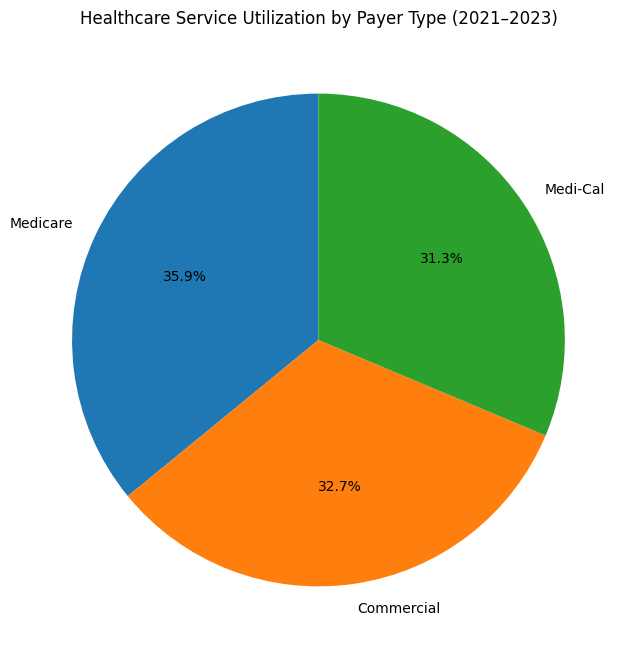

In [ ]:
# Group by payer type and calculate total service count
payer_utilization = (df.groupby("payer_type")["service_count"].sum().sort_values(ascending=False))
# Set chart size
plt.figure(figsize=(8,8))
# Creating pie chart
explode = (0.05, 0.05, 0.05)
plt.pie(payer_utilization,
    labels=payer_utilization.index,
    autopct="%1.1f%%",
    startangle=90)
# Add chart title
plt.title("Healthcare Service Utilization by Payer Type (2021–2023)")
# Displaying the chart
plt.show()

### Interpretation & Insights

- **Healthcare Utilization Distribution:** The pie chart shows the distribution of total healthcare service utilization across the three major payer types between 2021 to 2023.

- **Highest Utilization:** Medicare accounts for the largest share of healthcare service utilization at 35.9%, indicating the highest service demand among all payer types.

- **Balanced Payer Contribution:** Commercial insurance contributes 32.7%, followed by Medi-Cal at 31.3%, showing that healthcare utilization is relatively balanced across the three payer groups.

- **Overall Observation:** The difference between the highest and lowest payer share is only 4.6 percentage points, indicating that no single payer type overwhelmingly dominates healthcare service utilization.

- **Business Insight:** Understanding payer-wise utilization helps healthcare organizations optimize resource allocation, develop insurance-specific strategies, and support informed healthcare planning.

##**Multivariate Analysis**

**Objective3A - Demographic Analysis of Healthcare Service Utilization by Age Group and Assigned Sex at Birth**

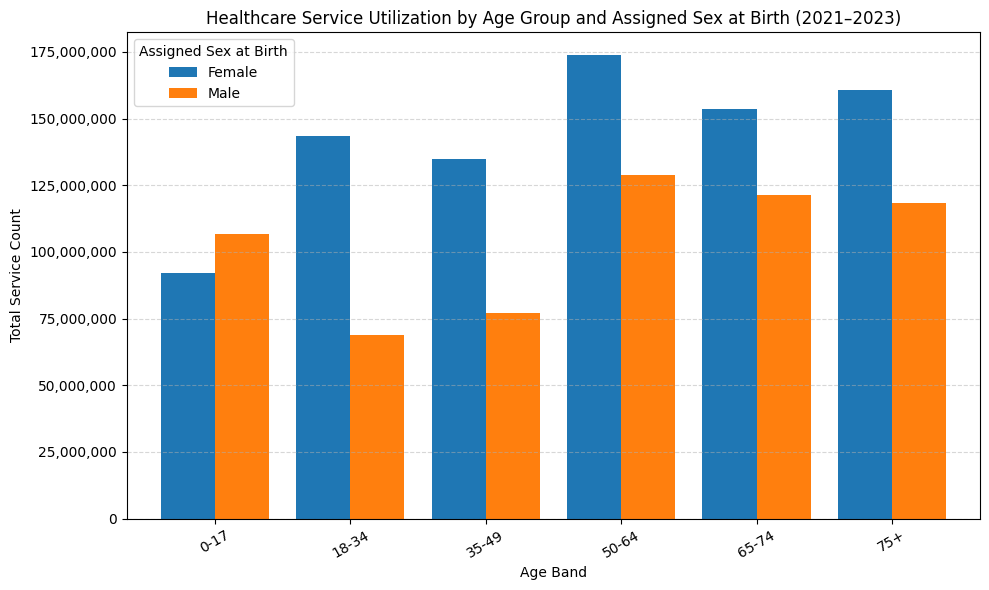

In [ ]:
# Group data by age band and assigned sex at birth
age_gender_utilization = (df.groupby(["age_band", "assigned_sex_at_birth"])["service_count"].sum().unstack())
# Creating clustered bar chart
age_gender_utilization.plot(
    kind="bar",
    figsize=(10,6),
    width=0.8)
# Add chart title
plt.title("Healthcare Service Utilization by Age Group and Assigned Sex at Birth (2021–2023)")
# Add x-axis label
plt.xlabel("Age Band")
# Add y-axis label
plt.ylabel("Total Service Count")
# Rotate x-axis labels
plt.xticks(rotation=30)
# Display y-axis in normal number format
plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}'))
# Add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Add legend
plt.legend(title="Assigned Sex at Birth")
# Adjust layout
plt.tight_layout()
# Displaying the chart
plt.show()

### Interpretation & Insights

- **Healthcare Utilization Across Age Groups:** This clustered bar chart compares total healthcare service utilization across different age groups between 2021 to 2023 for females and males.

- **Variation by Assigned Sex at Birth:** Female beneficiaries record higher healthcare service utilization in five of the six age groups, while males show slightly higher utilization only in the 0–17 age group.

- **Highest Healthcare Utilization:** The 50–64 age group records the highest healthcare service utilization for both females (approximately 167 million services) and males (approximately 122 million services), indicating the greatest demand among middle-aged adults.

- **Overall Observation:** Healthcare service utilization generally increases from younger to middle-aged groups and remains relatively high among older adults, with female utilization consistently exceeding male utilization in most age groups.

- **Business Insight:** Understanding utilization patterns by age group and assigned sex at birth helps healthcare providers optimize resource allocation, design targeted healthcare programs, and improve service planning for high-demand populations.

**Objective 3B - Regional Analysis of Healthcare Service Utilization by Covered California Region**

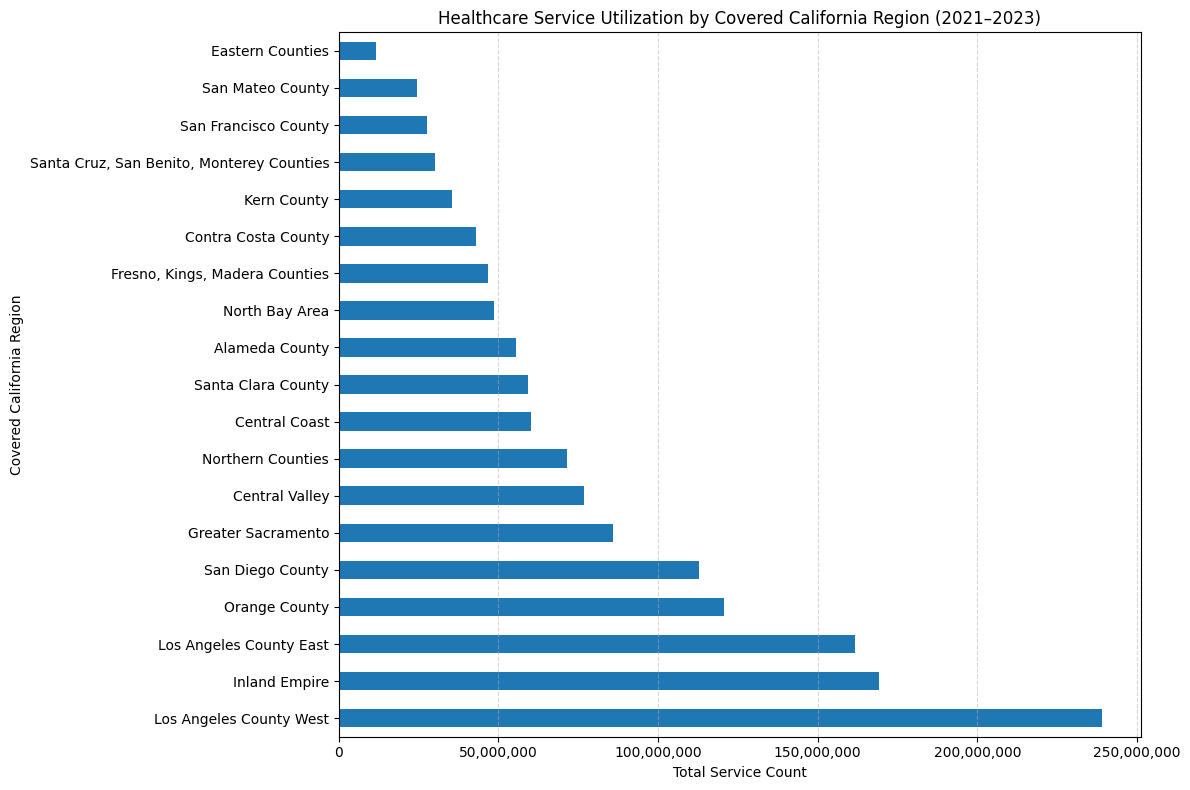

In [ ]:
# Group data by Covered California Region
region_utilization = (df.groupby("covered_california_region")["service_count"].sum().sort_values(ascending=False))
# Create horizontal bar chart
region_utilization.plot(
    kind="barh",
    figsize=(12,8))
# Add chart title
plt.title("Healthcare Service Utilization by Covered California Region (2021–2023)")
# Add x-axis label
plt.xlabel("Total Service Count")
# Add y-axis label
plt.ylabel("Covered California Region")
# Display x-axis in normal number format
plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}'))
# Add vertical grid lines
plt.grid(axis='x', linestyle='--', alpha=0.5)
# Adjust layout
plt.tight_layout()
# Display chart
plt.show()

### Interpretation & Insights

- **Regional Healthcare Utilization:** This horizontal bar chart compares total healthcare service utilization across Covered California regions between 2021 to 2023, highlighting regional differences in healthcare demand.

- **Highest Healthcare Utilization:** Los Angeles County West records the highest healthcare service utilization at approximately 243 million services, followed by Inland Empire (approximately 168 million) and Los Angeles County East (approximately 160 million).

- **Lowest Healthcare Utilization:** Eastern Counties record the lowest healthcare service utilization at approximately 12 million services, followed by San Mateo County (approximately 25 million) and San Francisco County (approximately 28 million).

- **Overall Observation:** Healthcare service utilization varies considerably across regions, with Los Angeles County West recording nearly twenty times more services than Eastern Counties.

- **Business Insight:** Identifying regional utilization patterns helps healthcare providers and policymakers allocate resources efficiently, strengthen healthcare planning, and prioritize investments in high-demand regions while improving access in lower-utilization areas.

##**Bivariate Analysis**

**Ojective 4A - Insurance Coverage Analysis By Payer Type**

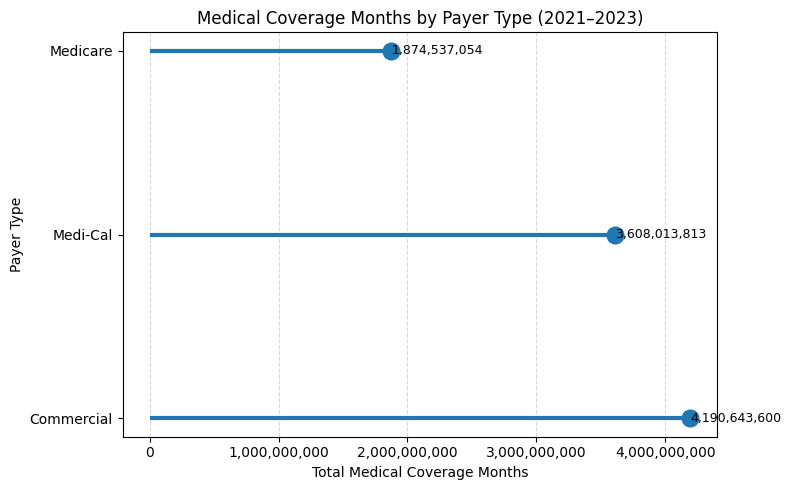

In [ ]:
# Group data by payer type
payer_coverage = (
    df.groupby("payer_type")["medical_coverage_months"].sum().sort_values(ascending=False))
plt.figure(figsize=(8,5))
# Draw stems
plt.hlines(
    y=payer_coverage.index,
    xmin=0,
    xmax=payer_coverage.values,
    linewidth=3)
# Draw dots
plt.plot(
    payer_coverage.values,
    payer_coverage.index,
    'o',
    markersize=12)
# Title
plt.title("Medical Coverage Months by Payer Type (2021–2023)")
# Axis labels
plt.xlabel("Total Medical Coverage Months")
plt.ylabel("Payer Type")
# Format x-axis
plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}'))
# Grid
plt.grid(axis='x', linestyle='--', alpha=0.5)
# Add value labels
for i, value in enumerate(payer_coverage.values):
    plt.text(
        value,
        i,
        f'{value:,.0f}',
        va='center',
        ha='left',
        fontsize=9)
# Layout
plt.tight_layout()
# Showing the chart
plt.show()

### Interpretation & Insights

- **Insurance Coverage Pattern by Payer Type:** This lollipop chart compares the total medical coverage months across different payer types between 2021 to 2023, highlighting differences in insurance coverage among Commercial, Medi-Cal, and Medicare plans.

- **Highest Medical Coverage:** Commercial insurance records the highest total medical coverage months (approximately 4.19 billion), followed by Medi-Cal (approximately 3.61 billion), indicating that these payer types account for the largest share of health insurance coverage during the study period.

- **Lowest Medical Coverage:** Medicare records the lowest total medical coverage months (approximately 1.87 billion) among the three payer types, reflecting a comparatively smaller share of total insurance coverage.

- **Business Insight:** Analyzing medical coverage months across different payer types helps healthcare administrators and policymakers understand insurance coverage distribution, optimize healthcare resource planning, allocate resources effectively, and support informed policy decisions to improve healthcare accessibility.

**Ojective 4B - Insurance Coverage Analysis by County**

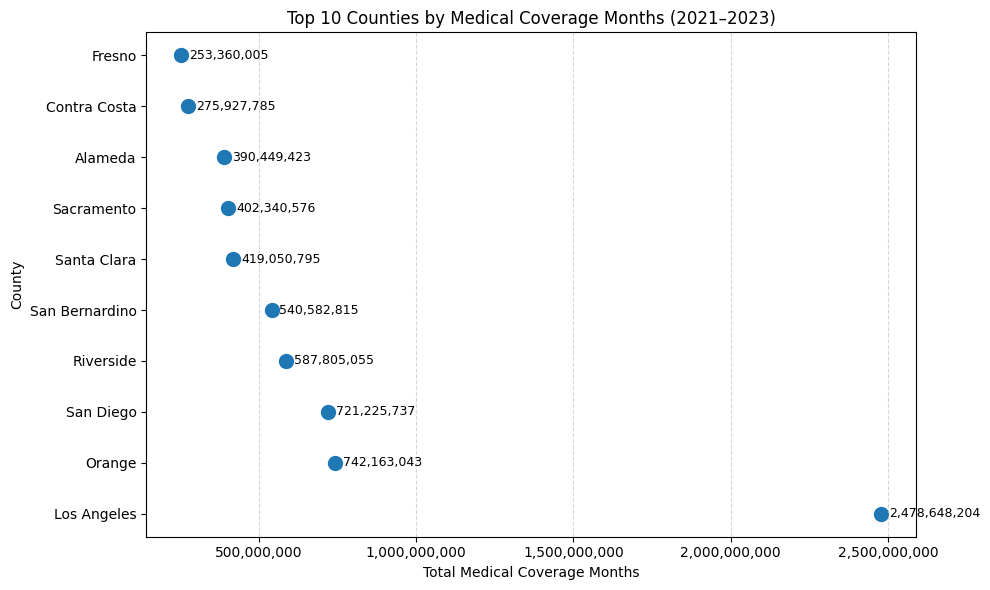

In [ ]:
# Group data by county and select the top 10 counties
county_coverage = (df.groupby("county_name")["medical_coverage_months"].sum().sort_values(ascending=False).head(10))
# Creating the figure
plt.figure(figsize=(10,6))
# Plot dots
plt.scatter(
    county_coverage.values,
    county_coverage.index,
    s=100)
# Chart title
plt.title("Top 10 Counties by Medical Coverage Months (2021–2023)")
# Axis labels
plt.xlabel("Total Medical Coverage Months")
plt.ylabel("County")
# Format x-axis
plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}'))
# Add grid
plt.grid(axis='x', linestyle='--', alpha=0.5)
# Add value labels
for i, value in enumerate(county_coverage.values):
    plt.text(
        value + county_coverage.max()*0.01,
        i,
        f'{value:,.0f}',
        va='center',
        fontsize=9)
# Adjusting the layout
plt.tight_layout()
# Displaying the chart
plt.show()

### Interpretation & Insights

- **County-wise Insurance Coverage:** This Cleveland dot plot compares the total medical coverage months across the top 10 counties in California between 2021 to 2023, highlighting differences in insurance coverage among counties.

- **Highest Medical Coverage:** Los Angeles County records the highest total medical coverage months (approximately 2.48 billion), followed by Orange County (approximately 742 million) and San Diego County (approximately 721 million), indicating a larger covered population and greater healthcare coverage in these counties.

- **Lower Medical Coverage:** Counties such as Fresno (approximately 253 million), Contra Costa (approximately 276 million), Alameda (approximately 390 million), and Sacramento (approximately 402 million) report comparatively lower medical coverage months among the top 10 counties, reflecting differences in population size and insurance coverage across counties.

- **Business Insight:** Identifying counties with higher and lower medical coverage months helps healthcare administrators and policymakers understand regional insurance coverage patterns, optimize healthcare resource allocation, and support data-driven planning for future healthcare programs.

##**Multivariate Analysis**

**Ojective 5 - To identify healthcare utilization trends over the period 2021–2023 and examine changes in service demand across different healthcare service categories**

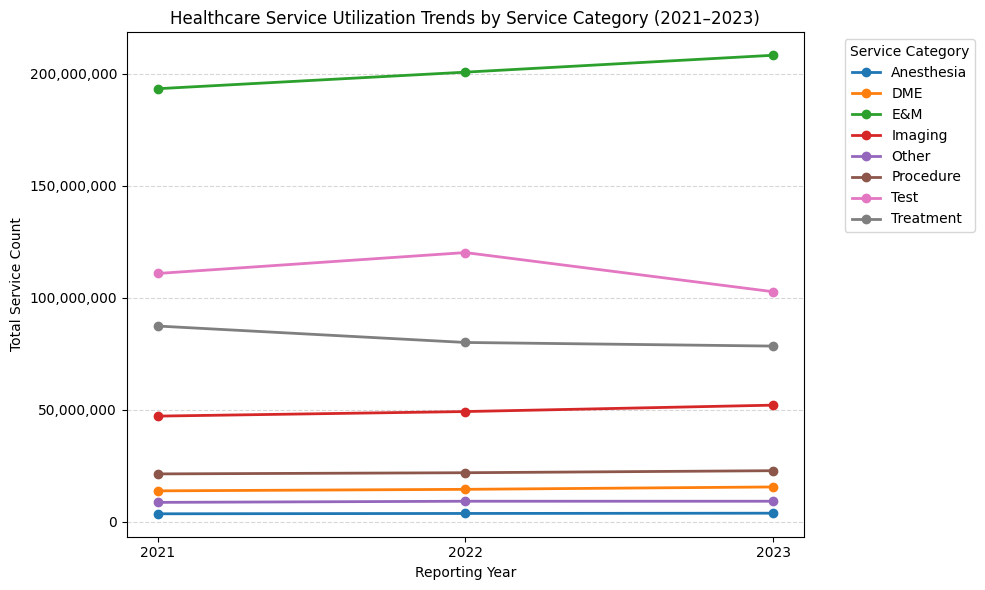

In [ ]:
# Group data by reporting year and service category
trend_analysis = (df.groupby(["reporting_year", "service_category"])["service_count"].sum().unstack())
# Create multi-line chart
trend_analysis.plot(
    kind="line",
    marker="o",
    linewidth=2,
    figsize=(10,6))
# Add chart title
plt.title("Healthcare Service Utilization Trends by Service Category (2021–2023)")
# Add x-axis label
plt.xlabel("Reporting Year")
# Add y-axis label
plt.ylabel("Total Service Count")
# Display only reporting years
plt.xticks([2021, 2022, 2023])
# Format y-axis values
plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}'))
# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Add legend
plt.legend(
    title="Service Category",
    bbox_to_anchor=(1.05,1),
    loc="upper left")
# Adjusting the layout
plt.tight_layout()
# Displaying the chart
plt.show()

### Interpretation & Insights

- **Healthcare Utilization Trends:** The multi-line chart illustrates healthcare service utilization trends across different service categories between 2021 to 2023, highlighting how healthcare service demand changed over the three-year period.

- **Increasing Service Demand:** E&M records the highest healthcare service utilization throughout the study period and shows a steady increase from 2021 to 2023, indicating consistent growth in demand for evaluation and management services.

- **Changing Service Utilization:** Test services increase from 2021 to 2022 before declining in 2023, while Treatment services show a gradual decline over the three-year period. Imaging shows a steady increase, whereas Procedure, DME, Other, and Anesthesia remain relatively stable with only minor changes.

- **Business Insight:** Analyzing healthcare utilization trends across different service categories helps healthcare administrators and policymakers identify changes in service demand, optimize healthcare resource allocation, improve operational planning, and support data-driven decision-making for future healthcare service delivery.